In [1]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import seaborn as sns
import time
from keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense ,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from keras.utils import to_categorical

In [2]:
#!/bin/bash
!kaggle datasets download datamunge/sign-language-mnist

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
sign-language-mnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
os.environ['KAGGLE_CONFIG_DIR'] = os.path.expanduser('~/.kaggle')

!kaggle datasets download -d datamunge/sign-language-mnis
with zipfile.ZipFile('sign-language-mnist.zip', 'r') as zip_ref:
    zip_ref.extractall('sign-language-mnist')

print("Dataset downloaded and unzipped successfully.")

403 - Forbidden - Permission 'datasets.get' was denied
Dataset downloaded and unzipped successfully.


In [4]:
import pandas as pd
train_df = pd.read_csv(r"C:\Users\ASUS\Downloads\archive (1)\sign_mnist_train.csv")
test_df = pd.read_csv(r"C:\Users\ASUS\Downloads\archive (1)\sign_mnist_test.csv")
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB


In [6]:
from sklearn.preprocessing import LabelBinarizer
X_train = train_df.drop(['label'],axis=1).values
train_label=train_df['label'].values

X_test=test_df.drop(['label'],axis=1).values
test_label=test_df['label'].values

lb=LabelBinarizer()
y_train=lb.fit_transform(train_label)
y_test=lb.fit_transform(test_label)

X_train = X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(27455, 28, 28, 1) (27455, 24) (7172, 28, 28, 1) (7172, 24)


In [8]:
class_names = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S',
    'T', 'U', 'V', 'W', 'X', 'Y'
]

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range=10,
        zoom_range = 0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=False,
        vertical_flip=False)

datagen.fit(X_train)

In [10]:
import numpy as np
unique_value = np.array(train_label)
np.unique(unique_value)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int64)

In [11]:
print(np.isnan(X_train).sum())

0


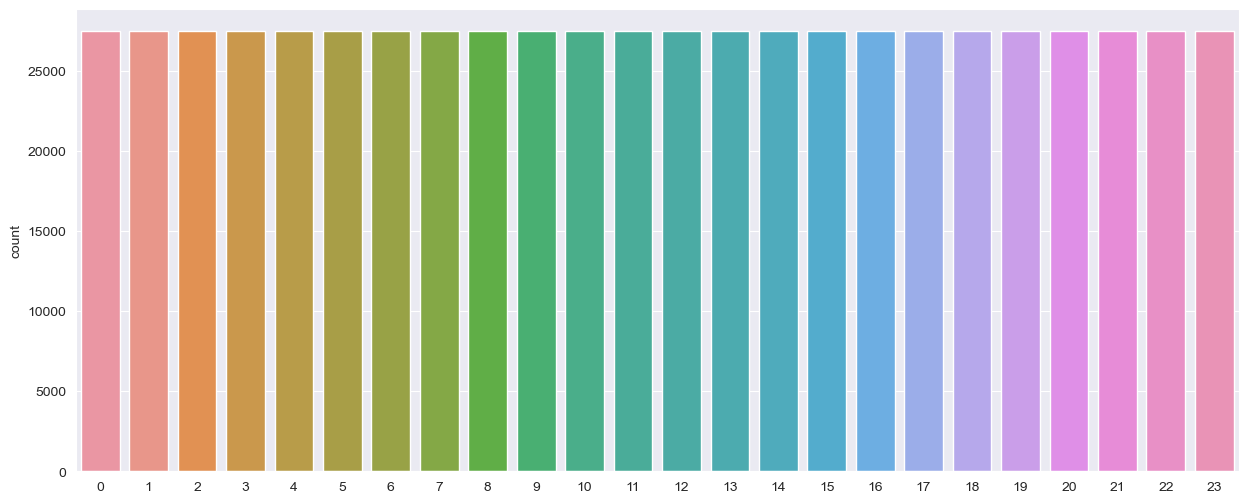

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
import seaborn as sns
sns.set_style("darkgrid");
sns.countplot(y_train);

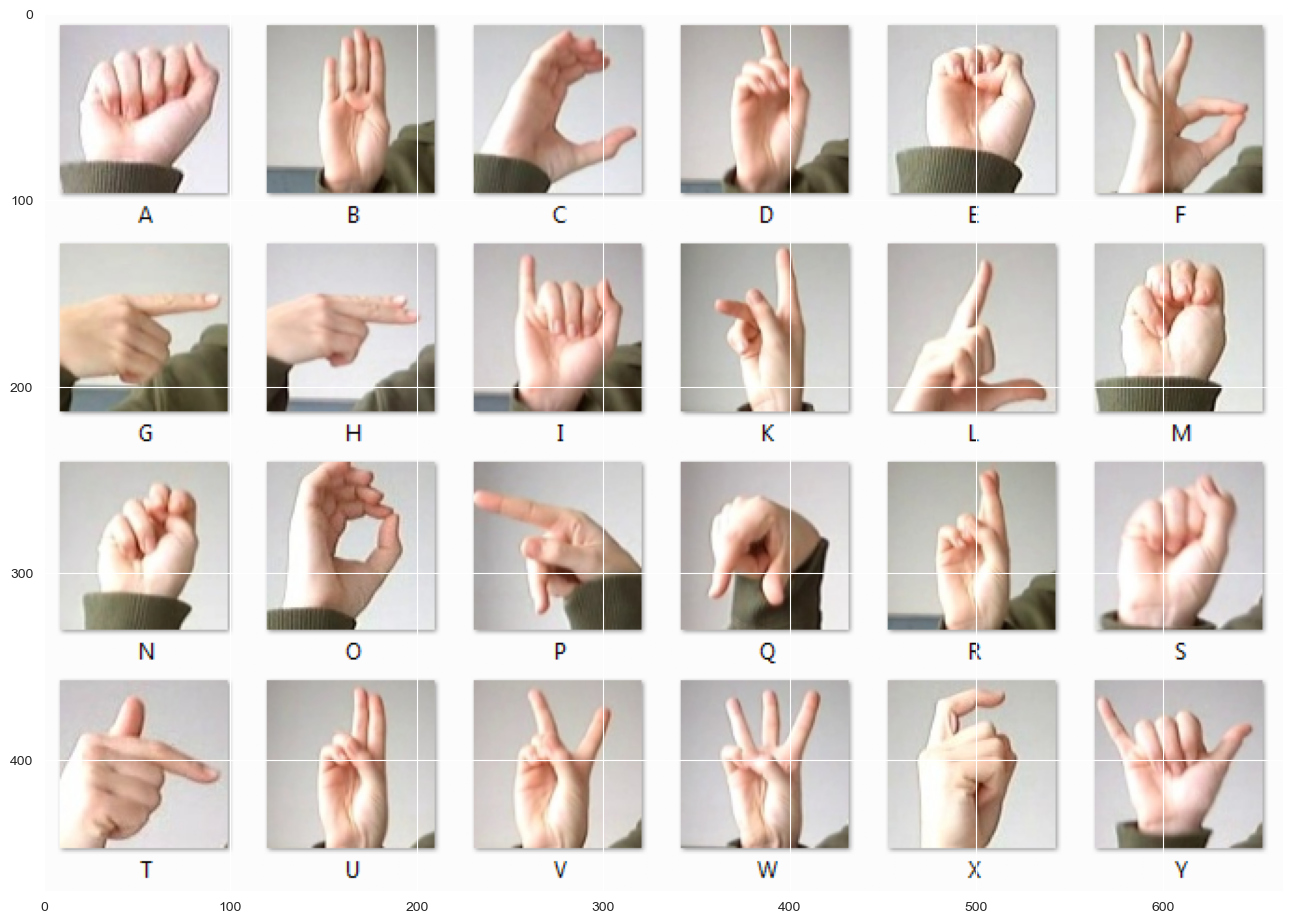

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize = (16,16))
img = plt.imread('sign-language-mnist/amer_sign2.png')
plt.imshow(img)
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

model0 = RandomForestClassifier(n_estimators=100, random_state=42)
model0.fit(X_train_flat, train_label)

y_pred_rf = model0.predict(X_test_flat)
accuracy_rf = accuracy_score(test_label, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf}")

Random Forest Accuracy: 0.8163692136084774


In [15]:
Model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(24,activation='softmax')
],name="Model1")
Model1.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

start_train_time = time.time()

history1=Model1.fit(X_train, y_train, epochs=20,validation_data=(X_test, y_test))
end_train_time = time.time()
training_time1 = end_train_time - start_train_time

C:\Users\ASUS\python\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2530 - loss: 2.5807 - val_accuracy: 0.4689 - val_loss: 1.7284
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5988 - loss: 1.3480 - val_accuracy: 0.5892 - val_loss: 1.3149
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6996 - loss: 1.0090 - val_accuracy: 0.6259 - val_loss: 1.2096
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7573 - loss: 0.8116 - val_accuracy: 0.6496 - val_loss: 1.1305
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8072 - loss: 0.6771 - val_accuracy: 0.6410 - val_loss: 1.1648
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8397 - loss: 0.5599 - val_accuracy: 0.6760 - val_loss: 1.0907
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8690 - loss: 0.4786 - val_accuracy: 0.6955 - val_loss: 1.0404
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8920 - loss: 0.3981 - val_accurac

In [16]:
Model1.summary()

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │           3,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 310,730 (1.19 MB)

 Trainable params: 103,576 (404.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 207,154 (809.20 KB)

In [17]:
model2 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation="softmax"),
    ],name="Model2"
)
model2.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
start_train_time = time.time()

history2=model2.fit(X_train, y_train, batch_size=32,epochs=20, validation_data=(X_test, y_test))
end_train_time = time.time()
training_time2 = end_train_time - start_train_time

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.4085 - loss: 2.0326 - val_accuracy: 0.8374 - val_loss: 0.5351
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.8913 - loss: 0.3417 - val_accuracy: 0.8942 - val_loss: 0.3506
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9505 - loss: 0.1600 - val_accuracy: 0.9131 - val_loss: 0.2959
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9674 - loss: 0.0980 - val_accuracy: 0.9272 - val_loss: 0.2520
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9784 - loss: 0.0710 - val_accuracy: 0.9260 - val_loss: 0.2976
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.9833 - loss: 0.0515 - val_accuracy: 0.9239 - val_loss: 0.2975
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9863 - loss: 0.0433 - val_accuracy: 0.9198 - val_loss: 0.2970
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - accuracy: 0.9883 - loss: 0.0351 - 

In [18]:
model2.summary()

Model: "Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │          38,424 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 171,722 (670.79 KB)

 Trainable params: 57,240 (223.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 114,482 (447.20 KB)

In [19]:
model3 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation="softmax"),
    ],name="Model3"
)
model3.compile(optimizer=RMSprop(),#changed
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
start_train_time = time.time()

history3=model3.fit(X_train, y_train, batch_size=32,epochs=20, validation_data=(X_test, y_test))
end_train_time = time.time()
training_time3 = end_train_time - start_train_time

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.3826 - loss: 2.1335 - val_accuracy: 0.7931 - val_loss: 0.6702
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.8694 - loss: 0.4107 - val_accuracy: 0.8766 - val_loss: 0.3672
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9423 - loss: 0.1814 - val_accuracy: 0.9090 - val_loss: 0.3170
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9675 - loss: 0.1019 - val_accuracy: 0.9041 - val_loss: 0.3103
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9797 - loss: 0.0674 - val_accuracy: 0.9215 - val_loss: 0.2932
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9837 - loss: 0.0506 - val_accuracy: 0.9237 - val_loss: 0.3448
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9883 - loss: 0.0374 - val_accuracy: 0.9140 - val_loss: 0.3606
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.9897 - loss: 0.0325 - 

In [20]:
model3.summary()

Model: "Model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 24)                  │          38,424 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,482 (447.20 KB)

 Trainable params: 57,240 (223.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,242 (223.61 KB)

In [21]:
model4 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        BatchNormalization(),#Added
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        BatchNormalization(),#Added
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),#added
        BatchNormalization(),#added
        layers.MaxPooling2D(pool_size=(2, 2)),#added
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation="softmax"),
    ],name="Model4"
)
model4.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
start_train_time = time.time()

history4=model4.fit(X_train, y_train, batch_size=32,epochs=20, validation_data=(X_test, y_test))
end_train_time = time.time()
training_time4 = end_train_time - start_train_time

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 71s 77ms/step - accuracy: 0.6463 - loss: 1.3631 - val_accuracy: 0.8568 - val_loss: 0.4332
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - accuracy: 0.9870 - loss: 0.0562 - val_accuracy: 0.8931 - val_loss: 0.3606
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.9918 - loss: 0.0321 - val_accuracy: 0.8970 - val_loss: 0.2934
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9911 - loss: 0.0305 - val_accuracy: 0.9083 - val_loss: 0.2869
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9954 - loss: 0.0174 - val_accuracy: 0.8555 - val_loss: 0.5213
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9894 - loss: 0.0312 - val_accuracy: 0.9453 - val_loss: 0.1434
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9959 - loss: 0.0141 - val_accuracy: 0.8770 - val_loss: 0.4584
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9945 - loss: 0.0196 - 

In [22]:
model4.summary()

Model: "Model4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 3, 3, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 24)                  │           3,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289,098 (1.10 MB)

 Trainable params: 96,216 (375.84 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 192,434 (751.70 KB)

In [23]:
model5 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.Dropout(0.2),#added
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.2),#decrease to 0.2
        layers.Dense(len(class_names), activation="softmax"),
    ],name="Model5")


model5.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
start_train_time = time.time()

history5=model5.fit(X_train, y_train, batch_size=32,epochs=20, validation_data=(X_test, y_test))
end_train_time = time.time()
training_time5 = end_train_time - start_train_time

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.7372 - loss: 0.9421 - val_accuracy: 0.9108 - val_loss: 0.2913
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9941 - loss: 0.0274 - val_accuracy: 0.8907 - val_loss: 0.3680
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9943 - loss: 0.0222 - val_accuracy: 0.9031 - val_loss: 0.3499
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.9166 - val_loss: 0.2698
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.9986 - loss: 0.0074 - val_accuracy: 0.8535 - val_loss: 0.5034
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9092 - val_loss: 0.3237
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9955 - loss: 0.0119 - val_accuracy: 0.9473 - val_loss: 0.2085
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.9978 - loss: 0.0082 - 

In [24]:
model5.summary()

Model: "Model5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 3, 3, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 24)                  │           3,096 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289,098 (1.10 MB)

 Trainable params: 96,216 (375.84 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 192,434 (751.70 KB)

In [6]:
from tensorflow.keras import models, layers
from tensorflow.keras.layers import BatchNormalization
import tensorflow as tf
import time  # Assuming you need it for timing

# Replace `class_names` with the actual number of classes
class_names = ['class1', 'class2', 'class3']  # Update with your actual classes

model6 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), activation="relu"),  # change the filtering to 75
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(50, kernel_size=(3, 3), activation="relu"),  # change the filtering to 50
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(25, kernel_size=(3, 3), activation="relu"),  # change the filtering to 25
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(len(class_names), activation="softmax"),
    ], name="Model6"
)

model6.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

start_train_time = time.time()


In [7]:
model6.summary()

Model: "Model6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 26, 26, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 26, 26, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 13, 13, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 11, 11, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 11, 11, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 11, 11, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 5, 5, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 3, 3, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 3, 3, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 1, 1, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              78 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,503 (181.65 KB)

 Trainable params: 46,203 (180.48 KB)

 Non-trainable params: 300 (1.17 KB)

In [11]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape the data to include a channel dimension (grayscale images)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize the data to the range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [14]:
from tensorflow.keras.utils import to_categorical

# Define the correct number of classes
num_classes = 10  # Update based on your dataset
class_names = [f'class{i}' for i in range(num_classes)]  # Example class names

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Update model definition
model7 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),  # Ensure correct number of classes
    ], name="Model7"
)

# Compile the model
model7.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [15]:
model7.summary()

Model: "Model7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)                   │ (None, 28, 28, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 28, 28, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 14, 14, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 14, 14, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 14, 14, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 7, 7, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 7, 7, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 4, 4, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           4,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,435 (197.01 KB)

 Trainable params: 50,135 (195.84 KB)

 Non-trainable params: 300 (1.17 KB)

In [17]:
model8 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dense(units=512, activation='relu'),  # Corrected to use layers.Dense
        layers.Dropout(0.3),  # Added a dropout of 30%
        layers.Dense(len(class_names), activation="softmax"),
    ], name="Model8"
)

model8.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

start_train_time = time.time()


In [18]:
model8.summary()

Model: "Model8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 28, 28, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_33               │ (None, 28, 28, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 14, 14, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 14, 14, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_34               │ (None, 14, 14, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 7, 7, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_35               │ (None, 7, 7, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 4, 4, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         205,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 256,867 (1003.39 KB)

 Trainable params: 256,567 (1002.21 KB)

 Non-trainable params: 300 (1.17 KB)

In [21]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define learning rate reduction
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', 
    patience=2, 
    verbose=1, 
    factor=0.5, 
    min_lr=0.00001
)

# Define model9
model9 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dense(units=512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation="softmax"),
    ], name="Model9"
)

# Compile the model
model9.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model with the ReduceLROnPlateau callback
history9 = model9.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[learning_rate_reduction]
)


Epoch 1/20


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32, 10, 10, 10), output.shape=(32, 10)

In [22]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau

# One-hot encode labels
num_classes = 10  # Update this based on your dataset
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Verify data shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Learning rate reduction callback
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', 
    patience=2, 
    verbose=1, 
    factor=0.5, 
    min_lr=0.00001
)

# Define and compile the model
model9 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dense(units=512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="Model9"
)

model9.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model
history9 = model9.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[learning_rate_reduction]
)


X_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10, 10, 10, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10, 10, 10, 10)
Epoch 1/20


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32, 10, 10, 10, 10), output.shape=(32, 10)

In [24]:
# Check and preprocess y_train
print("Original y_train shape:", y_train.shape)

# Flatten and convert to integers if needed
y_train = y_train.ravel().astype('int32')
y_test = y_test.ravel().astype('int32')

print("Processed y_train shape:", y_train.shape)
print("Sample y_train values:", y_train[:10])

# Downsample data for testing (optional)
X_train = X_train[:10000]
y_train = y_train[:10000]
X_test = X_test[:2000]
y_test = y_test[:2000]

# One-hot encode
from tensorflow.keras.utils import to_categorical

num_classes = 10  # Update based on your dataset
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("y_train shape after encoding:", y_train.shape)


# Define the model
model9 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dense(units=512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="Model9"
)

model9.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model
history9 = model9.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[learning_rate_reduction]
)


Original y_train shape: (60000, 10, 10, 10, 10)
Processed y_train shape: (600000000,)
Sample y_train values: [1 0 0 0 0 0 0 0 0 0]
y_train shape after encoding: (10000, 10)
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8696 - loss: 0.4265 - val_accuracy: 0.1005 - val_loss: 1.2408 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8993 - loss: 0.3221 - val_accuracy: 0.9000 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8951 - loss: 0.3300 - val_accuracy: 0.9000 - val_loss: 0.3508 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8987 - loss: 0.3165
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.8987 - loss: 0.3165 - val_accuracy: 0.9000 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - acc

In [25]:
model9.summary()

Model: "Model9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)                   │ (None, 28, 28, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 28, 28, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_42 (MaxPooling2D)      │ (None, 14, 14, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 14, 14, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 14, 14, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_44 (Conv2D)                   │ (None, 7, 7, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_44               │ (None, 7, 7, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_44 (MaxPooling2D)      │ (None, 4, 4, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 512)                 │         205,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 770,003 (2.94 MB)

 Trainable params: 256,567 (1002.21 KB)

 Non-trainable params: 300 (1.17 KB)

 Optimizer params: 513,136 (1.96 MB)

In [27]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callback for learning rate reduction
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', patience=2, verbose=1, factor=0.5, min_lr=0.00001
)

# Define the model
model10 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        Dense(units=512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation="softmax"),
    ],
    name="Model10"
)

# Compile the model
model10.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model
history10 = model10.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[learning_rate_reduction]
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8714 - loss: 0.4488 - val_accuracy: 0.5795 - val_loss: 1.7040 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9047 - loss: 0.3110 - val_accuracy: 0.8995 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8986 - loss: 0.3224 - val_accuracy: 0.8995 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9060 - loss: 0.3046 - val_accuracy: 0.9000 - val_loss: 0.3456 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8984 - loss: 0.3184 - val_accuracy: 0.8995 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8957 - loss: 0.3217
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8958 - los

In [28]:
model10.summary()

Model: "Model10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)                   │ (None, 28, 28, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_48               │ (None, 28, 28, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_48 (MaxPooling2D)      │ (None, 14, 14, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 14, 14, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_49               │ (None, 14, 14, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_49 (MaxPooling2D)      │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 7, 7, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_50               │ (None, 7, 7, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_50 (MaxPooling2D)      │ (None, 4, 4, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_16 (Flatten)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 512)                 │         205,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 770,003 (2.94 MB)

 Trainable params: 256,567 (1002.21 KB)

 Non-trainable params: 300 (1.17 KB)

 Optimizer params: 513,136 (1.96 MB)

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define the ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,   # Random rotations
    width_shift_range=0.2,   # Horizontal shifts
    height_shift_range=0.2,  # Vertical shifts
    shear_range=0.2,     # Shearing transformation
    zoom_range=0.2,      # Zooming
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode='nearest'   # Filling missing pixels after transformations
)

# Learning rate reduction callback
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', patience=2, verbose=1, factor=0.5, min_lr=0.00001
)

# Define your model (Model11)
model11 = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(75, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(50, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Conv2D(25, kernel_size=(3, 3), strides=1, padding='same', activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'),
        layers.Flatten(),
        layers.Dense(units=512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation="softmax"),
    ],
    name="Model11"
)

# Compile the model
model11.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train the model using the data generator for data augmentation
start_train_time = time.time()

history11 = model11.fit(
    datagen.flow(X_train, y_train, batch_size=128),  # Using the data generator
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[learning_rate_reduction]
)

end_train_time = time.time()
training_time11 = end_train_time - start_train_time
print(f"Training time for model11: {training_time11} seconds")


C:\Users\ASUS\python\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.8335 - loss: 0.6069 - val_accuracy: 0.0835 - val_loss: 2.2071 - learning_rate: 0.0010
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.8988 - loss: 0.3517 - val_accuracy: 0.1000 - val_loss: 1.7595 - learning_rate: 0.0010
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8973 - loss: 0.3460 - val_accuracy: 0.1000 - val_loss: 1.6726 - learning_rate: 0.0010
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.9006 - loss: 0.3314 - val_accuracy: 0.1650 - val_loss: 1.4453 - learning_rate: 0.0010
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.8967 - loss: 0.3397 - val_accuracy: 0.7470 - val_loss: 0.9117 - learning_rate: 0.0010
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.8962 - loss: 0.3379 - val_accuracy: 0.8860 - val_loss: 0.5894 - learning_rate: 0.0010
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.9038 - loss: 0.

In [31]:
model11.summary()

Model: "Model11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)                   │ (None, 28, 28, 75)          │             750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_54               │ (None, 28, 28, 75)          │             300 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_54 (MaxPooling2D)      │ (None, 14, 14, 75)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_55 (Conv2D)                   │ (None, 14, 14, 50)          │          33,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_55               │ (None, 14, 14, 50)          │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_55 (MaxPooling2D)      │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 7, 7, 25)            │          11,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_56               │ (None, 7, 7, 25)            │             100 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_56 (MaxPooling2D)      │ (None, 4, 4, 25)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_18 (Flatten)                 │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 512)                 │         205,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 770,003 (2.94 MB)

 Trainable params: 256,567 (1002.21 KB)

 Non-trainable params: 300 (1.17 KB)

 Optimizer params: 513,136 (1.96 MB)

In [33]:

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
accuracy_fn = tf.keras.metrics.CategoricalAccuracy()

def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes}:{seconds:02d}"


def eval_model(model: tf.keras.Model,
               data_loader: tf.data.Dataset,
               loss_fn: tf.keras.losses.Loss,
               accuracy_fn: tf.keras.metrics.Metric,
               training_time: float):

    loss = 0
    num_batches = 0
    accuracy_fn.reset_state()

    for X, y in data_loader:
        y_pred = model(X, training=False)
        batch_loss = loss_fn(y, y_pred)
        loss += batch_loss
        num_batches += 1
        accuracy_fn.update_state(y, y_pred)

    loss /= num_batches
    acc = accuracy_fn.result().numpy()

    return {"model_name": model.name,
            "model_loss": float(loss),
            "model_acc": float(acc),
            "execution_time": format_time(training_time)}

In [34]:
model_results1 = eval_model(model=Model1,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn, training_time=training_time1)
model_results2 = eval_model(model=model2,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time2)
model_results3 = eval_model(model=model3,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time3)
model_results4 = eval_model(model=model4,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time4)
model_results5 = eval_model(model=model5,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time5)
model_results6 = eval_model(model=model6,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time6)
model_results7 = eval_model(model=model7,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time7)
model_results8 = eval_model(model=model8,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time8)
model_results9 = eval_model(model=model9,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time9)
model_results10 = eval_model(model=model10,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time10)
model_results11 = eval_model(model=model11,data_loader=test_dataset,loss_fn=loss_fn,accuracy_fn=accuracy_fn,training_time=training_time11)

print(model_results1)
print(model_results2)
print(model_results3)
print(model_results4)
print(model_results5)
print(model_results6)
print(model_results7)
print(model_results8)
print(model_results9)
print(model_results10)
print(model_results11)

NameError: name 'Model1' is not defined

In [ ]:
compare_results = pd.DataFrame([model_results1, model_results2,model_results3, model_results4,model_results5, model_results6,model_results7, model_results8,model_results9, model_results10,model_results11])


In [32]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

NameError: name 'compare_results' is not defined

In [35]:
probability_model = tf.keras.Sequential([model11, 
                                         tf.keras.layers.Softmax()])
predictions = probability_model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [42]:
def plot_image(i, predictions_array, true_label, img):
  true_label = np.argmax(true_label[i])
  img = img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = np.argmax(true_label[i])
  plt.grid(False)
  plt.xticks(range(24))
  plt.yticks([])
  thisplot = plt.bar(range(24), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

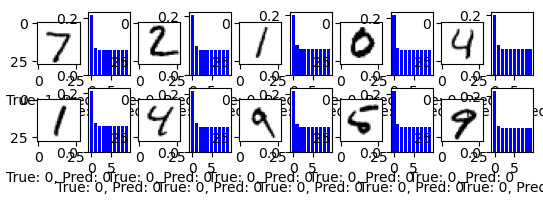

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_image(i, predictions_array, true_label, img):
    true_label = np.argmax(true_label[i])  # Get the index of the true label
    img = img[i]  # Get the corresponding image
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)
    plt.xlabel(f"True: {true_label}, Pred: {np.argmax(predictions_array)}")  # Display true and predicted labels

def plot_value_array(i, predictions_array, true_label):
    true_label = np.argmax(true_label[i])  # Get the index of the true label
    plt.grid(False)
    plt.bar(range(10), predictions_array, color="blue")
    plt.xlabel(f"True: {true_label}, Pred: {np.argmax(predictions_array)}")

# Example of usage
num_images = 10
num_rows = 5
num_cols = 5

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], y_test, X_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions[i], y_test)

plt.show()


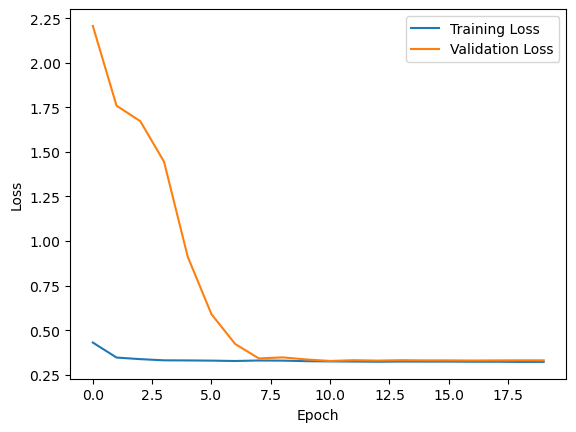

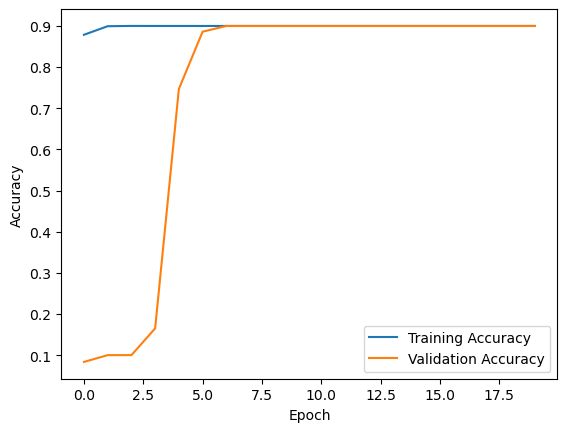

In [43]:

def plot_training_history(history):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_training_history(history11)

Confusion matrix shape: (2, 2)


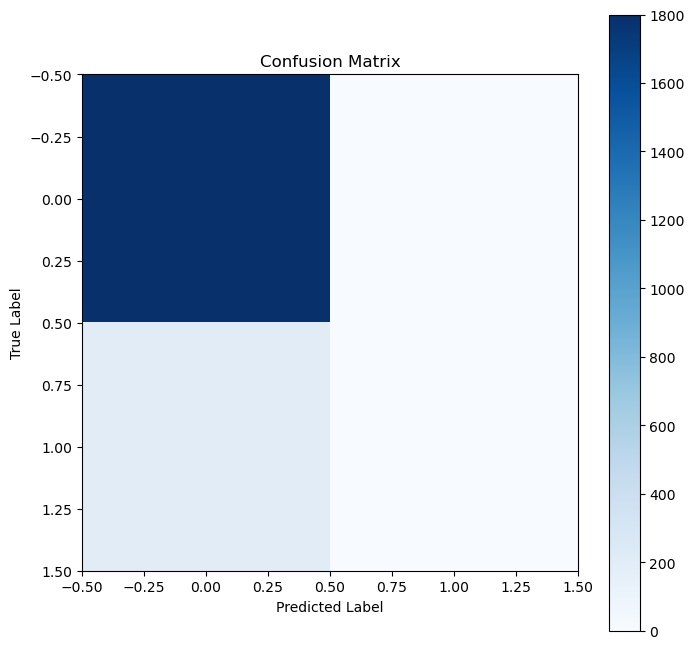

In [46]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example confusion matrix with 2 classes (adjust to your actual number of classes)
cm = confusion_matrix(y_test.argmax(axis=1), predictions.argmax(axis=1))

# Check the shape of the confusion matrix
print(f"Confusion matrix shape: {cm.shape}")

# Create DataFrame based on the confusion matrix
# Adjust the index and columns to match the shape of the confusion matrix
cm_df = pd.DataFrame(cm, index=[0, 1], columns=[0, 1])

# Plot the confusion matrix
plt.figure(figsize=(8,8))
plt.imshow(cm_df, cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [49]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Load the model
model = load_model('sign_mnist_cnn_10_Epochs.h5')

# Recompile the model (if you want to evaluate or train it again)
model.compile(optimizer=Adam(), 
              loss=CategoricalCrossentropy(from_logits=False), 
              metrics=['accuracy'])


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# تحميل النموذج المدرب
model = tf.keras.models.load_model('sign_mnist_cnn_10_Epochs.h5')
print("Model loaded successfully.")

# تجميع النموذج (اختياري)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# أسماء الفئات
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

# إعداد الكاميرا
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Camera not accessible.")
    exit()

# إعداد تحسين البيانات
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# هنا، افترض أن لديك بيانات التدريب X_train و y_train
# إذا لم تكن لديك بيانات تدريب، يجب عليك تحميلها أو إنشاؤها هنا.
# على سبيل المثال:
# X_train = ... # بيانات الصور (numpy array)
# y_train = ... # تسميات البيانات (numpy array)

# استخدام datagen لتوليد بيانات جديدة أثناء التدريب
# قم بتدريب النموذج
# model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=50)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Can't receive frame (stream end?). Exiting ...")
        break

    # معالجة الصورة
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (28, 28))
    img = img.reshape(1, 28, 28, 1)
    img = img / 255.0

    # إجراء التنبؤ
    try:
        predictions = model.predict(img)
        class_index = np.argmax(predictions)
        class_name = class_names[class_index]
        confidence = np.max(predictions)  # الحصول على قيمة الثقة
    except Exception as e:
        print(f"Error during prediction: {e}")
        continue

    # عرض التنبؤ على الصورة
    cv2.putText(frame, f'Prediction: {class_name}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.putText(frame, f'Confidence: {confidence:.2f}', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # عرض الصورة
    cv2.imshow('Sign Language Recognition', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [50]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [2]:
'''import cv2
cap = cv2.VideoCapture(1)
while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Can't receive frame (stream end?). Exiting ...")
        break

    # Flip the frame horizontally (change camera view from left to right or vice versa)
    frame = cv2.flip(frame, 1)

    # معالجة الصورة
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (28, 28))
    img = img.reshape(1, 28, 28, 1)
    img = img / 255.0

    # إجراء التنبؤ
    try:
        predictions = model.predict(img)
        class_index = np.argmax(predictions)
        class_name = class_names[class_index]
        confidence = np.max(predictions)  # الحصول على قيمة الثقة
    except Exception as e:
        print(f"Error during prediction: {e}")
        continue

    # عرض التنبؤ على الصورة
    cv2.putText(frame, f'Prediction: {class_name}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.putText(frame, f'Confidence: {confidence:.2f}', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # عرض الصورة
    cv2.imshow('Sign Language Recognition', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not defined
Error during prediction: name 'model' is not d

KeyboardInterrupt: 

In [ ]:
'''import cv2
import numpy as np
import tensorflow as tf

# تحميل النموذج المدرب
model = tf.keras.models.load_model('sign_mnist_cnn_10_Epochs.h5')
print("Model loaded successfully.")

# أسماء الفئات
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

# إعداد الكاميرا
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Camera not accessible.")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Can't receive frame (stream end?). Exiting ...")
        break

    # إضافة نافذة إرشادية لتوجيه المستخدم
    cv2.rectangle(frame, (100, 100), (400, 400), (255, 255, 255), 2)
    cv2.putText(frame, 'Place your hand inside the box', (110, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # اقتصاص الإطار داخل المربع
    cropped_frame = frame[100:400, 100:400]

    # معالجة الصورة (تحويلها إلى تدرجات رمادية ثم تغيير الحجم)
    gray_img = cv2.cvtColor(cropped_frame, cv2.COLOR_BGR2GRAY)
    resized_img = cv2.resize(gray_img, (28, 28))
    normalized_img = resized_img / 255.0  # تطبيع القيم إلى النطاق [0, 1]
    input_img = normalized_img.reshape(1, 28, 28, 1)  # إعداد الإدخال للنموذج

    # إجراء التنبؤ باستخدام النموذج
    try:
        predictions = model.predict(input_img)
        class_index = np.argmax(predictions)
        confidence = np.max(predictions)

        if confidence > 0.5:  # حد الثقة
            class_name = class_names[class_index]
        else:
            class_name = "Uncertain"
    except Exception as e:
        print(f"Error during prediction: {e}")
        continue

    # عرض التنبؤ على الإطار
    cv2.putText(frame, f'Prediction: {class_name}', (10, 450), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Confidence: {confidence:.2f}', (10, 480), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # عرض الإطار
    cv2.imshow('Sign Language Recognition', frame)

    # الخروج عند الضغط على "q"
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# تحرير الموارد
cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# تحميل النموذج المدرب
model = tf.keras.models.load_model('sign_mnist_cnn_10_Epochs.h5')
print("Model loaded successfully.")

# أسماء الفئات
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

# إعداد الكاميرا
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Camera not accessible.")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Can't receive frame (stream end?). Exiting ...")
        break

    # عكس الإطار أفقياً
    frame = cv2.flip(frame, 1)

    # عرض نافذة إرشادية لتوجيه المستخدم
    cv2.rectangle(frame, (100, 100), (400, 400), (255, 255, 255), 2)
    cv2.putText(frame, 'Place your hand inside the box', (110, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # اقتصاص الإطار داخل المربع
    cropped_frame = frame[100:400, 100:400]

    # معالجة الصورة (تحويلها إلى تدرجات رمادية ثم تغيير الحجم)
    gray_img = cv2.cvtColor(cropped_frame, cv2.COLOR_BGR2GRAY)
    resized_img = cv2.resize(gray_img, (28, 28))
    normalized_img = resized_img / 255.0  # تطبيع القيم إلى النطاق [0, 1]
    input_img = normalized_img.reshape(1, 28, 28, 1)  # إعداد الإدخال للنموذج

    # إجراء التنبؤ باستخدام النموذج
    try:
        predictions = model.predict(input_img)
        class_index = np.argmax(predictions)
        confidence = np.max(predictions)

        if confidence > 0.5:  # حد الثقة
            class_name = class_names[class_index]
        else:
            class_name = "Uncertain"
    except Exception as e:
        print(f"Error during prediction: {e}")
        continue

    # عرض التنبؤ على الإطار
    cv2.putText(frame, f'Prediction: {class_name}', (10, 450), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f'Confidence: {confidence:.2f}', (10, 480), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # عرض الإطار
    cv2.imshow('Sign Language Recognition', frame)

    # الخروج عند الضغط على "q"
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# تحرير الموارد
cap.release()
cv2.destroyAllWindows()


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

In [4]:
import cv2
import mediapipe as mp

mpHands = mp.solutions.hands
hands = mpHands.Hands()
mpDraw = mp.solutions.drawing_utils
tipIds = [4, 8, 12, 16, 20]

cap = cv2.VideoCapture(1)

if not cap.isOpened():
    print("Error: Camera not accessible.")
    exit()

while True:
    success, img = cap.read()

    if not success:
        print("Error: Failed to capture image.")
        continue

    img = cv2.flip(img, 1)
    imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(imgRGB)
    lmList = []

    if results.multi_hand_landmarks:
        for handLms in results.multi_hand_landmarks:
            for id, lm in enumerate(handLms.landmark):
                h, w, c = img.shape
                cx, cy = int(lm.x * w), int(lm.y * h)
                lmList.append([id, cx, cy])
                mpDraw.draw_landmarks(img, handLms, mpHands.HAND_CONNECTIONS)

            if len(lmList) == 21:
                fingers = []

                # Check if thumb is up with a tolerance
                thumb_up = lmList[tipIds[0]][1] < lmList[tipIds[0] - 2][1]
                fingers.append(1 if thumb_up else 0)

                for tip in range(1, 5):
                    finger_up = lmList[tipIds[tip]][2] < lmList[tipIds[tip] - 2][2]
                    fingers.append(1 if finger_up else 0)

                totalFingers = fingers.count(1)
                
                # Print and display the total fingers
                print(totalFingers)
                cv2.putText(img, f'{totalFingers}', (40, 80), cv2.FONT_HERSHEY_SIMPLEX,
                            3, (0, 0, 255), 6)

    cv2.imshow('Hand Tracker', img)

    if cv2.waitKey(5) & 0xFF == 'q':
        break

cap.release()
cv2.destroyAllWindows()

4
4
4
5
1
4
4
5
5
5
5
4
5
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
4
5
4
1
2
2
1
1
1
5
1
1
1
1
1
1
1
1
4
4
5
5
5
5
5
5
5
5
5
5
1
1
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
3
3
3
3
3
3
3
3
3
3
2
2
2
2
2
2
2
1
1
1
1
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
4
4
4
4
4
4
4
4
3
3
3
3
3
3
3
3
3
2
2
2
2
2
2
2
2
2
1
1
1
1
1
2
2
2
1
0
4
5
4
5
1
1
0
0
1
1
1
1
1
5
5
5
5
5
5
5
5
5
5
1
1
1
1
1
2
1
1
2
4
3
4
4
4
4
1
1
4
4
3
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
0
1
2
2
0
1
1
0
1
1
1
1
1
1
1
1
1
1
1
2
1
5
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4
3
1
1
5
5
5
5
2
2
2
2
2
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
4
4
4
4
4
4
4
4
4
4
4
4
4
3
3
3
3
3
3
3
3
3
3
3
3
2
2
2
2
2
2
5
5
5
5
5
1
4
4
4
4
4
4
4
4
4
4
4
4
4
4
4


KeyboardInterrupt: 